# Bipolar Disorder, Lithium Response and Genomics

Project pipeline:

**PubMed literature → candidate genes → GEO blood expression validation**

In [1]:
!pip install biopython pandas tqdm matplotlib openpyxl scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 33.1 MB/s eta 0:00:00


In [6]:
import re
import time
from datetime import date
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

from Bio import Entrez
from tqdm import tqdm
from pathlib import Path
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import NMF
from google.colab import drive
import os

In [7]:


drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/BioScience")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

print("Project folder:", PROJECT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder: /content/drive/MyDrive/BioScience


## Query and Data Collection

In [8]:
Entrez.email = "h.forghani@campus.unimib.it"

SLEEP = 0.4
today = date.today()

# last 5 years
try:
    start_date = date(today.year - 5, today.month, today.day)
except ValueError:
    start_date = date(today.year - 5, 2, 28)

date_filter = f'("{start_date:%Y/%m/%d}"[Date - Publication] : "{today:%Y/%m/%d}"[Date - Publication])'

query = f"""
(
    "bipolar disorder"[MeSH Terms]
    OR "bipolar disorder"[Title/Abstract]
    OR "bipolar affective disorder"[Title/Abstract]
    OR "manic-depressive"[Title/Abstract]
)
AND
(
    "lithium"[All Fields]
    OR "lithium carbonate"[All Fields]
)
AND
(
    "genes"[MeSH Terms]
    OR "gene expression"[Title/Abstract]
    OR "transcriptome"[Title/Abstract]
    OR "transcriptomics"[Title/Abstract]
    OR "genomics"[Title/Abstract]
    OR "genetic"[Title/Abstract]
    OR "pharmacogenomics"[Title/Abstract]
    OR "pharmacogenetics"[Title/Abstract]
)
AND
{date_filter}
AND
english[Language]
"""

print(query)


(
    "bipolar disorder"[MeSH Terms]
    OR "bipolar disorder"[Title/Abstract]
    OR "bipolar affective disorder"[Title/Abstract]
    OR "manic-depressive"[Title/Abstract]
)
AND
(
    "lithium"[All Fields]
    OR "lithium carbonate"[All Fields]
)
AND
(
    "genes"[MeSH Terms]
    OR "gene expression"[Title/Abstract]
    OR "transcriptome"[Title/Abstract]
    OR "transcriptomics"[Title/Abstract]
    OR "genomics"[Title/Abstract]
    OR "genetic"[Title/Abstract]
    OR "pharmacogenomics"[Title/Abstract]
    OR "pharmacogenetics"[Title/Abstract]
)
AND
("2021/06/02"[Date - Publication] : "2026/06/02"[Date - Publication])
AND
english[Language]



In [9]:
def search_pubmed(query, batch_size=100):

    handle = Entrez.esearch(
        db="pubmed",
        term=query,
        retmax=0,
        usehistory="y"
    )
    search_results = Entrez.read(handle)
    handle.close()

    total_count = int(search_results["Count"])
    webenv = search_results["WebEnv"]
    query_key = search_results["QueryKey"]

    print("Total articles found:", total_count)

    all_articles = []
    for start in range(0, total_count, batch_size):
        fetch_handle = Entrez.efetch(
            db="pubmed",
            rettype="xml",
            retmode="xml",
            retstart=start,
            retmax=batch_size,
            webenv=webenv,
            query_key=query_key
        )

        batch_records = Entrez.read(fetch_handle)
        fetch_handle.close()

        all_articles.extend(batch_records["PubmedArticle"])
        print(f"Fetched {min(start + batch_size, total_count)} / {total_count}")

        time.sleep(SLEEP)

    return {"PubmedArticle": all_articles}


records = search_pubmed(query)
print("fetched articles:", len(records["PubmedArticle"]))

Total articles found: 127
Fetched 100 / 127
Fetched 127 / 127
fetched articles: 126


## Parse PubMed Metadata

In [10]:
def get_year(article):
    pub_date = article.get("Journal", {}).get("JournalIssue", {}).get("PubDate", {})
    if "Year" in pub_date:
        return str(pub_date["Year"])
    if "MedlineDate" in pub_date:
        match = re.search(r"\d{4}", str(pub_date["MedlineDate"]))
        return match.group(0) if match else None
    return None


def get_abstract(article):
    if "Abstract" not in article:
        return ""
    parts = article["Abstract"].get("AbstractText", [])
    return " ".join([str(p) for p in parts])


def get_article_type(medline):
    types = medline.get("Article", {}).get("PublicationTypeList", [])
    return "; ".join([str(t) for t in types])


def get_mesh_terms(medline):
    mesh_list = medline.get("MeshHeadingList", [])
    terms = []
    for item in mesh_list:
        descriptor = item.get("DescriptorName", "")
        if descriptor:
            terms.append(str(descriptor))
    return "; ".join(terms)


def get_keywords(medline):
    keywords = []
    for kw_list in medline.get("KeywordList", []):
        for kw in kw_list:
            keywords.append(str(kw))
    return "; ".join(keywords)


def get_journal(article):
    return article.get("Journal", {}).get("Title", "")


def get_authors(article, max_authors=6):
    authors = []
    for author in article.get("AuthorList", [])[:max_authors]:
        first = author.get("ForeName", "")
        last = author.get("LastName", "")
        full = f"{first} {last}".strip()
        if full:
            authors.append(full)
    return "; ".join(authors)


def get_first_affiliation(article):
    for author in article.get("AuthorList", []):
        affs = author.get("AffiliationInfo", [])
        if affs:
            return affs[0].get("Affiliation", "")
    return ""


rows = []

for item in records["PubmedArticle"]:
    medline = item.get("MedlineCitation", {})
    article = medline.get("Article", {})

    pmid = str(medline.get("PMID", ""))
    title = str(article.get("ArticleTitle", ""))
    abstract = get_abstract(article)

    rows.append({
        "pmid": pmid,
        "year": get_year(article),
        "title": title,
        "abstract": abstract,
        "journal": get_journal(article),
        "authors": get_authors(article),
        "first_affiliation": get_first_affiliation(article),
        "article_type": get_article_type(medline),
        "mesh_terms": get_mesh_terms(medline),
        "keywords": get_keywords(medline),
        "has_abstract": len(abstract.strip()) > 0,
        "text": f"{title} {abstract}".strip()
    })

df = pd.DataFrame(rows)

df["year_numeric"] = pd.to_numeric(df["year"], errors="coerce")
df["text_lower"] = df["text"].str.lower()

print("Total fetched articles:", len(df))
print("Unique PMIDs:", df["pmid"].nunique())
print("Articles with abstract:", int(df["has_abstract"].sum()))

df.head()

Total fetched articles: 126
Unique PMIDs: 126
Articles with abstract: 124


,pmid,year,title,abstract,journal,authors,first_affiliation,article_type,mesh_terms,keywords,has_abstract,text,year_numeric,text_lower
0,42144802,2026,Genetic Linkage for Bipolar Disorder to the Di...,Bipolar disorder (BD) is among the most herita...,Bipolar disorders,Albert H C Wong; Andrew D Paterson; Nicole M R...,Campbell Family Mental Health Research Institu...,Journal Article,Humans; Bipolar Disorder; Genetic Linkage; Mal...,bipolar; depression; genetics; linkage analysi...,True,Genetic Linkage for Bipolar Disorder to the Di...,2026,genetic linkage for bipolar disorder to the di...
1,41989970,2026,Circadian and sleep-related polygenic scores i...,Introduction Circadian rhythms are reflected t...,Neuropsychobiology,Marina Zafrilla-López; Daniel Herrera-Escartín...,,Journal Article,,,True,Circadian and sleep-related polygenic scores i...,2026,circadian and sleep-related polygenic scores i...
2,41955765,2026,Shared and distinct effects of mood stabilizer...,Mood stabilizers (MS) are the cornerstone of m...,European neuropsychopharmacology : the journal...,Vincent Hennion; Arthna Rathes; Alicja Puszkie...,Optimisation Thérapeutique en Neuropharmacolog...,Journal Article,,Bipolar disorder; DNA methylation; Epigenetics...,True,Shared and distinct effects of mood stabilizer...,2026,shared and distinct effects of mood stabilizer...
3,41935281,2026,Genetic predictors of lithium response in an e...,Several lines of evidence suggest that genetic...,Annals of general psychiatry,Abebe Ejigu Hailu; Solomon Teferra; Ephrem Eng...,Department of Pharmacology and Clinical Pharma...,Journal Article,,Bipolar disorder; Ethiopia; Genetics; Lithium;...,True,Genetic predictors of lithium response in an e...,2026,genetic predictors of lithium response in an e...
4,41901356,2026,Genetic Polymorphisms Associated with Lithium ...,<b>Background/Objectives</b>: Management of bi...,"Pharmaceuticals (Basel, Switzerland)",Ovinuchi Ejiohuo; Aleksandra Szczepankiewicz,"Department of Psychiatric Genetics, Poznan Uni...",Journal Article,,bipolar disorder; genetic polymorphism; in sil...,True,Genetic Polymorphisms Associated with Lithium ...,2026,genetic polymorphisms associated with lithium ...


## Data Quality

In [11]:
def contains_any(text, terms):
    text = str(text).lower()
    for term in terms:
        pattern = r"\b" + re.escape(term.lower()) + r"\b"
        if re.search(pattern, text):
            return True
    return False


bipolar_terms = [
    "bipolar disorder",
    "bipolar affective disorder",
    "manic depressive",
    "manic-depressive"
]

lithium_terms = [
    "lithium",
    "lithium carbonate"
]

response_terms = [
    "lithium response",
    "treatment response",
    "responder",
    "responders",
    "non-responder",
    "non-responders",
    "nonresponder",
    "nonresponders"
]

genomic_terms = [
    "gene",
    "genes",
    "genetic",
    "genetics",
    "genomic",
    "genomics",
    "gene expression",
    "transcriptome",
    "transcriptomic",
    "transcriptomics",
    "rna-seq",
    "rna sequencing",
    "microarray",
    "pharmacogenomics",
    "pharmacogenetics"
]


df["mentions_bipolar"] = df["text_lower"].apply(lambda x: contains_any(x, bipolar_terms))
df["mentions_lithium"] = df["text_lower"].apply(lambda x: contains_any(x, lithium_terms))
df["mentions_response"] = df["text_lower"].apply(lambda x: contains_any(x, response_terms))
df["mentions_genomics"] = df["text_lower"].apply(lambda x: contains_any(x, genomic_terms))

df["relevant"] = (
    df["mentions_bipolar"]
    & df["mentions_lithium"]
    & df["mentions_genomics"]
    & df["has_abstract"]
)

df["lithium_response_relevant"] = (
    df["relevant"]
    & df["mentions_response"]
)

df["is_review"] = df["article_type"].str.lower().str.contains("review", na=False)
df["is_preprint"] = df["article_type"].str.lower().str.contains("preprint", na=False)

df["title_norm"] = (
    df["title"]
    .str.lower()
    .str.replace(r"[^a-z0-9 ]", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

qc_summary = pd.DataFrame([{
    "total_articles": len(df),
    "unique_pmids": df["pmid"].nunique(),
    "with_abstract": int(df["has_abstract"].sum()),
    "mentions_bipolar": int(df["mentions_bipolar"].sum()),
    "mentions_lithium": int(df["mentions_lithium"].sum()),
    "mentions_response": int(df["mentions_response"].sum()),
    "mentions_genomics": int(df["mentions_genomics"].sum()),
    "relevant": int(df["relevant"].sum()),
    "lithium_response_relevant": int(df["lithium_response_relevant"].sum()),
    "reviews": int(df["is_review"].sum()),
    "preprints": int(df["is_preprint"].sum()),
    "duplicate_titles": int(df.duplicated("title_norm", keep=False).sum())
}])

display(qc_summary)

relevant_df = df[df["relevant"]].copy()
response_df = df[df["lithium_response_relevant"]].copy()

print("relevant:", len(relevant_df))
print("Lithium response relevant:", len(response_df))

,total_articles,unique_pmids,with_abstract,mentions_bipolar,mentions_lithium,mentions_response,mentions_genomics,relevant,lithium_response_relevant,reviews,preprints,duplicate_titles
0,126,126,124,120,121,52,121,111,49,32,10,12


relevant: 111
Lithium response relevant: 49


In [12]:
# duplicate checking
df["title_norm"] = (
    df["title"]
    .fillna("")
    .str.lower()
    .str.replace(r"[^a-z0-9 ]", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Define important article-level features to keep
important_columns = [
    "pmid",
    "year",
    "title",
    "abstract",
    "journal",
    "article_type",
    "mesh_terms",
    "keywords",
    "first_affiliation",
    "has_abstract",
    "mentions_bipolar",
    "mentions_lithium",
    "mentions_response",
    "mentions_genomics",
    "relevant",
    "lithium_response_relevant",
    "is_review",
    "is_preprint",
    "title_norm",
    "text"
]

# Keep only columns that actually exist in df
important_columns = [col for col in important_columns if col in df.columns]



# A) Raw corpus


raw_articles = df[important_columns].copy()
output= PROJECT_DIR/ "raw_lit_data.csv"
raw_articles.to_csv(
    output, index=False
)

print("Raw data saved:")
print("_raw_data.csv")
print("Raw articles:", len(raw_articles))

# B) Clean corpus

clean_all = relevant_df.copy()

clean_primary = relevant_df[
    (relevant_df["is_review"] == False) &
    (relevant_df["is_preprint"] == False)
].copy()
output_clean= PROJECT_DIR/ "clean_rel_data.csv"
clean_all.to_csv(output_clean, index=False)
output_pri = PROJECT_DIR/ "clean_pri_data.csv"
clean_primary.to_csv(output_pri, index=False)

print("Clean all:", len(clean_all))
print("Clean primary:", len(clean_primary))

clean_pmids = set(relevant_df["pmid"])

removed_articles = df[~df["pmid"].isin(clean_pmids)].copy()

removed_articles["exclusion_reason"] = ""

removed_articles.loc[removed_articles["has_abstract"] == False, "exclusion_reason"] += "No abstract; "
removed_articles.loc[removed_articles["relevant"] == False, "exclusion_reason"] += "Not relevant; "

if "is_preprint" in removed_articles.columns:
    removed_articles.loc[removed_articles["is_preprint"] == True, "exclusion_reason"] += "Preprint; "

removed_articles = removed_articles[important_columns + ["exclusion_reason"]].copy()

removed_articles.to_csv(
    "removed_or_irrelevant_articles.csv",
    index=False
)

print("\nRemoved/irrelevant file saved:")
print("removed_or_irrelevant_articles.csv")
print("Removed articles:", len(removed_articles))

Raw data saved:
_raw_data.csv
Raw articles: 126
Clean all: 111
Clean primary: 74

Removed/irrelevant file saved:
removed_or_irrelevant_articles.csv
Removed articles: 15


## Exploratory Data Analysis

In [13]:
analysis_df = relevant_df.copy()

if len(analysis_df) < 20:
    analysis_df = df[df["has_abstract"]].copy()
    print("corpus is small; using all articles with abstracts for exploratory analysis.")

print("EDA corpus size:", len(analysis_df))

EDA corpus size: 111


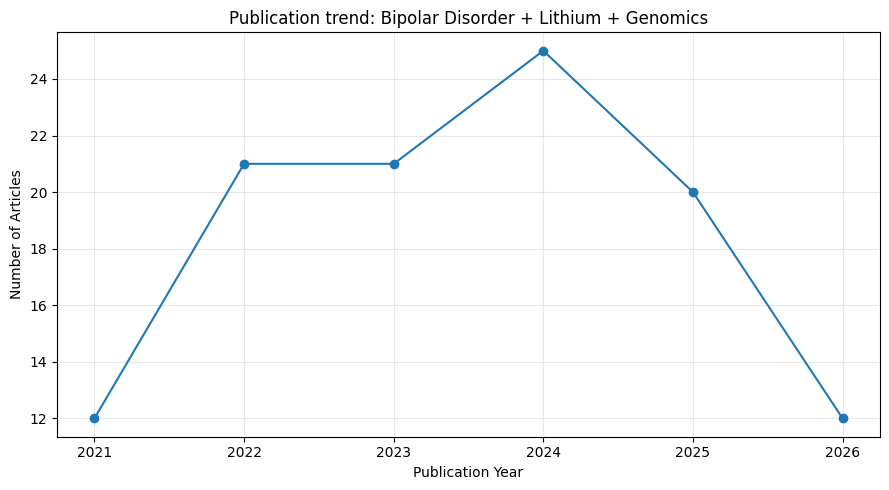

,year_numeric,n_articles
0,2021,12
1,2022,21
2,2023,21
3,2024,25
4,2025,20
5,2026,12


In [14]:
# Publication trend
year_counts = (
    analysis_df
    .dropna(subset=["year_numeric"])
    .groupby("year_numeric")
    .size()
    .reset_index(name="n_articles")
)

plt.figure(figsize=(9, 5))
plt.plot(year_counts["year_numeric"], year_counts["n_articles"], marker="o")
plt.xlabel("Publication Year")
plt.ylabel("Number of Articles")
plt.title("Publication trend: Bipolar Disorder + Lithium + Genomics")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_01_publication_trend.png", dpi=300)
plt.show()

year_counts

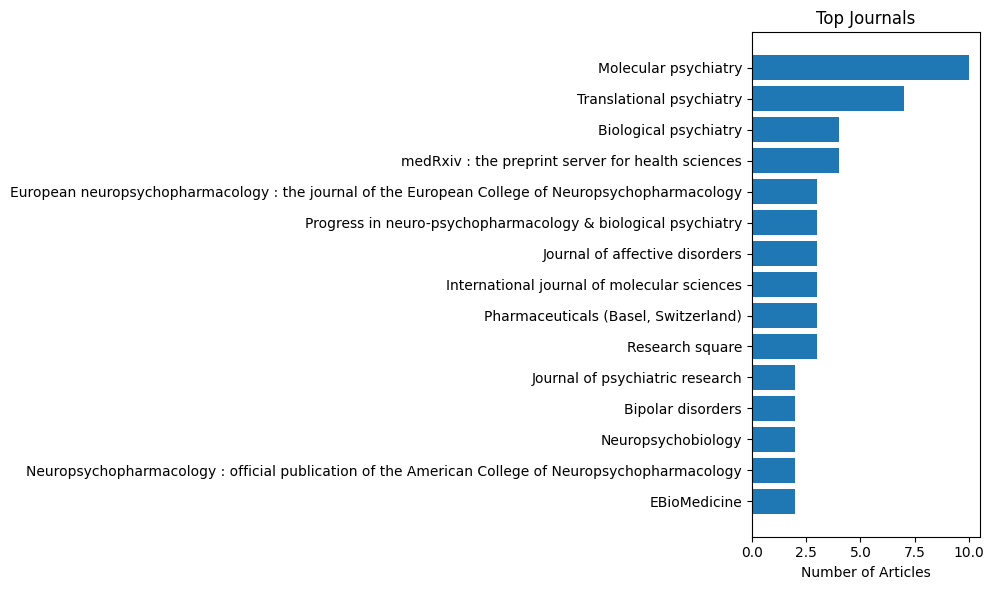

,journal,n_articles
0,Molecular psychiatry,10
1,Translational psychiatry,7
2,Biological psychiatry,4
3,medRxiv : the preprint server for health sciences,4
4,European neuropsychopharmacology : the journal...,3
5,Progress in neuro-psychopharmacology & biologi...,3
6,Journal of affective disorders,3
7,International journal of molecular sciences,3
8,"Pharmaceuticals (Basel, Switzerland)",3
9,Research square,3


In [15]:
# Top journals
top_journals = (
    analysis_df["journal"]
    .value_counts()
    .head(15)
    .reset_index()
)
top_journals.columns = ["journal", "n_articles"]

plt.figure(figsize=(10, 6))
plt.barh(top_journals["journal"][::-1], top_journals["n_articles"][::-1])
plt.xlabel("Number of Articles")
plt.title("Top Journals")
plt.tight_layout()
plt.savefig("fig_02_top_journals.png", dpi=300)
plt.show()

top_journals

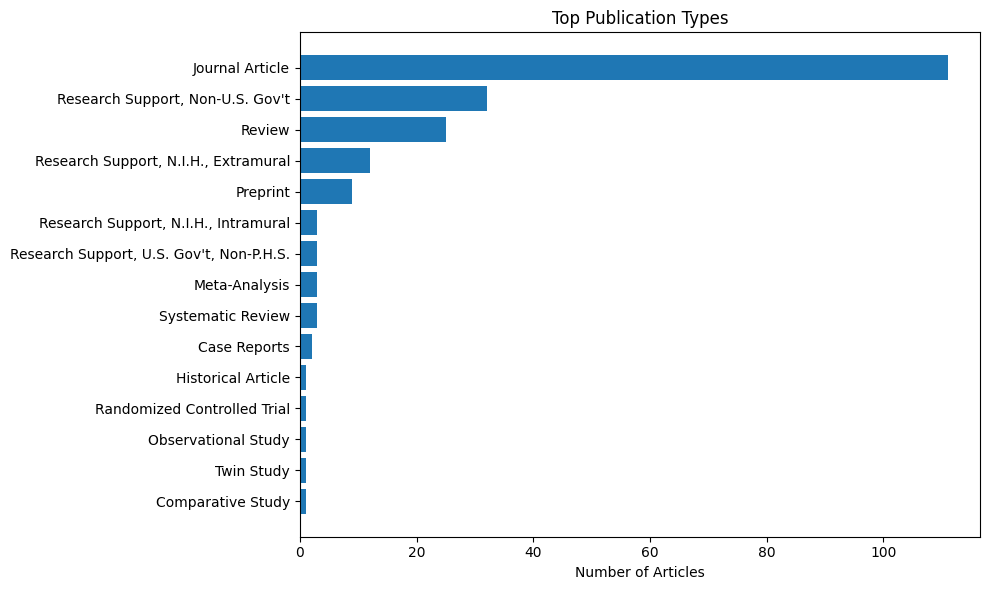

,article_type,n_articles
0,Journal Article,111
1,"Research Support, Non-U.S. Gov't",32
2,Review,25
3,"Research Support, N.I.H., Extramural",12
4,Preprint,9
5,"Research Support, N.I.H., Intramural",3
6,"Research Support, U.S. Gov't, Non-P.H.S.",3
7,Meta-Analysis,3
8,Systematic Review,3
9,Case Reports,2


In [16]:
# Article types
article_type_counts = (
    analysis_df["article_type"]
    .fillna("")
    .str.split("; ")
    .explode()
    .replace("", pd.NA)
    .dropna()
    .value_counts()
    .head(15)
    .reset_index()
)
article_type_counts.columns = ["article_type", "n_articles"]

plt.figure(figsize=(10, 6))
plt.barh(article_type_counts["article_type"][::-1], article_type_counts["n_articles"][::-1])
plt.xlabel("Number of Articles")
plt.title("Top Publication Types")
plt.tight_layout()
plt.savefig("fig_03_article_types.png", dpi=300)
plt.show()

article_type_counts

## Text Preprocessing

In [17]:
custom_stopwords = set("""
a about above after again against all am an and any are as at be because been before being below between both but by
can did do does doing down during each few for from further had has have having he her here hers herself him himself his
how i if in into is it its itself just me more most my myself no nor not now of off on once only or other our ours ourselves
out over own same she should so some such than that the their theirs them themselves then there these they this those through
to too under until up very was we were what when where which while who whom why will with you your yours yourself yourselves
""".split())

domain_stopwords = set("""
bd bpd bp li lithium sub sup mg ml kg pvalue pvalues ci sd se or rr hr
study studies result results finding findings found significant significantly
may also using used use based associated association effect effects
patient patients disorder disorders treatment response gene genes genetic
genomic genomics expression data analysis
""".split())

generic_stopwords = set("""
clinical potential research evidence however related specific model models
reported reports review reviews paper papers article articles
approach approaches method methods aim aims objective objectives
background conclusion conclusions non
""".split())

all_stopwords = sorted(custom_stopwords | domain_stopwords | generic_stopwords)


def basic_clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


analysis_df["clean_text"] = analysis_df["text"].apply(basic_clean_text)

analysis_df[["pmid", "year", "title", "clean_text"]].head()

,pmid,year,title,clean_text
0,42144802,2026,Genetic Linkage for Bipolar Disorder to the Di...,genetic linkage for bipolar disorder to the di...
1,41989970,2026,Circadian and sleep-related polygenic scores i...,circadian and sleep-related polygenic scores i...
2,41955765,2026,Shared and distinct effects of mood stabilizer...,shared and distinct effects of mood stabilizer...
3,41935281,2026,Genetic predictors of lithium response in an e...,genetic predictors of lithium response in an e...
4,41901356,2026,Genetic Polymorphisms Associated with Lithium ...,genetic polymorphisms associated with lithium ...


## Top Words, Bigrams and TF-IDF

In [18]:
# Top unigrams and bigrams by frequency
count_vectorizer = CountVectorizer(
    stop_words=all_stopwords,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85
)

count_matrix = count_vectorizer.fit_transform(analysis_df["clean_text"])
terms = count_vectorizer.get_feature_names_out()
term_counts = count_matrix.sum(axis=0).A1

term_freq_df = pd.DataFrame({
    "term": terms,
    "count": term_counts
}).sort_values("count", ascending=False)

display(term_freq_df.head(30))

output2 = PROJECT_DIR/ "top_terms_bigrams.csv"
term_freq_df.head(50).to_csv(output2, index=False)

,term,count
1666,mood,75
2276,risk,74
1584,mechanisms,66
2088,psychiatric,63
496,cell,62
266,analyses,53
544,circadian,52
1460,levels,51
891,drug,51
780,depression,51


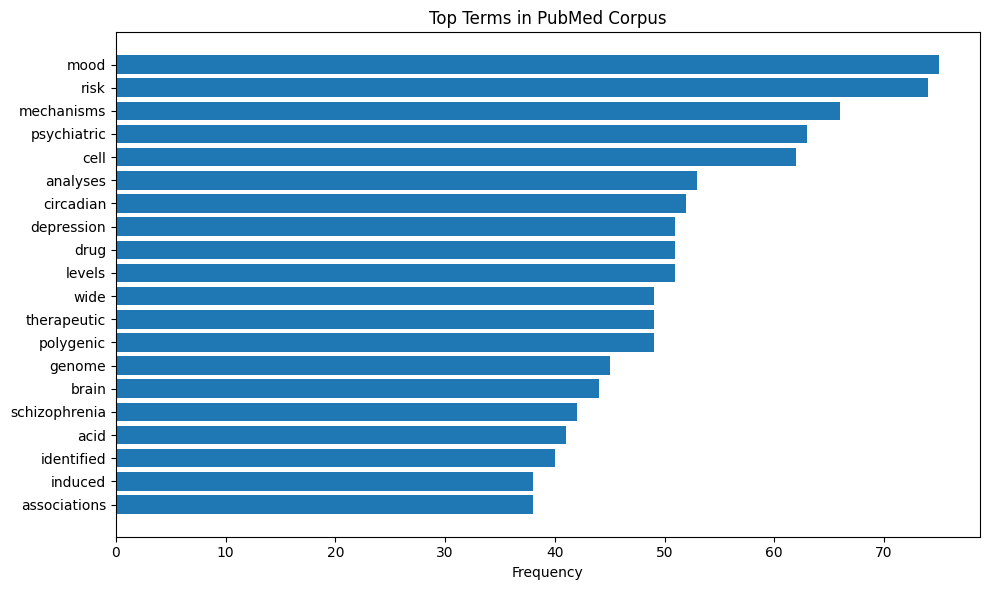

In [19]:
top_terms = term_freq_df.head(20).sort_values("count", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_terms["term"], top_terms["count"])
plt.xlabel("Frequency")
plt.title("Top Terms in PubMed Corpus")
plt.tight_layout()
plt.savefig("fig_04_top_terms.png", dpi=300)
plt.show()

In [20]:
# TF-IDF terms
tfidf_vectorizer = TfidfVectorizer(
    stop_words=all_stopwords,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85
)

tfidf_matrix = tfidf_vectorizer.fit_transform(analysis_df["clean_text"])
tfidf_terms = tfidf_vectorizer.get_feature_names_out()
tfidf_scores = tfidf_matrix.mean(axis=0).A1

tfidf_df = pd.DataFrame({
    "term": tfidf_terms,
    "mean_tfidf": tfidf_scores
}).sort_values("mean_tfidf", ascending=False)

display(tfidf_df.head(30))

tfidf_df.head(50).to_csv("05_top_terms_tfidf.csv", index=False)

,term,mean_tfidf
1584,mechanisms,0.024864
1666,mood,0.023259
544,circadian,0.022216
2276,risk,0.022186
496,cell,0.021179
2088,psychiatric,0.019791
780,depression,0.019635
1939,polygenic,0.019387
891,drug,0.019325
266,analyses,0.018915


## Topic Modeling with NMF

In [21]:
n_topics = 4

if tfidf_matrix.shape[0] < n_topics:
    n_topics = max(2, tfidf_matrix.shape[0])

nmf_model = NMF(
    n_components=n_topics,
    random_state=42,
    init="nndsvda",
    max_iter=500
)

topic_matrix = nmf_model.fit_transform(tfidf_matrix)
topic_term_matrix = nmf_model.components_

def top_terms_for_topic(topic_idx, n_top=12):
    topic_weights = topic_term_matrix[topic_idx]
    top_indices = topic_weights.argsort()[::-1][:n_top]
    return [(tfidf_terms[i], topic_weights[i]) for i in top_indices]

topic_rows = []
for topic_idx in range(n_topics):
    top_terms = top_terms_for_topic(topic_idx, n_top=12)
    topic_rows.append({
        "topic_id": topic_idx,
        "top_terms": ", ".join([t for t, w in top_terms])
    })

topics_df = pd.DataFrame(topic_rows)
display(topics_df)

analysis_df["dominant_topic"] = topic_matrix.argmax(axis=1)
analysis_df["topic_strength"] = topic_matrix.max(axis=1)

topics_df.to_csv("06_nmf_topics.csv", index=False)
analysis_df[["pmid", "year", "title", "dominant_topic", "topic_strength"]].to_csv("07_article_topics.csv", index=False)

,topic_id,top_terms
0,0,"mechanisms, mood, drug, cell, psychiatric, the..."
1,1,"pgs, pgss, polygenic, continuous, categorical,..."
2,2,"akt, pi3k, pi3k akt, focal adhesion, focal, ad..."
3,3,"cacna1c, levels, subjects, protein levels, ser..."


In [22]:
# Representative articles for each topic
representatives = []

for topic_id in range(n_topics):
    temp = (
        analysis_df[analysis_df["dominant_topic"] == topic_id]
        .sort_values("topic_strength", ascending=False)
        .head(5)
    )
    for _, row in temp.iterrows():
        representatives.append({
            "topic_id": topic_id,
            "topic_terms": topics_df.loc[topics_df["topic_id"] == topic_id, "top_terms"].iloc[0],
            "pmid": row["pmid"],
            "year": row["year"],
            "title": row["title"],
            "topic_strength": row["topic_strength"]
        })

representatives_df = pd.DataFrame(representatives)
display(representatives_df)

representatives_df.to_csv("08_topic_representative_articles.csv", index=False)

,topic_id,topic_terms,pmid,year,title,topic_strength
0,0,"mechanisms, mood, drug, cell, psychiatric, the...",37730845,2023,CaMKK2 as an emerging treatment target for bip...,0.200473
1,0,"mechanisms, mood, drug, cell, psychiatric, the...",41795042,2026,Leveraging the genetics of psychiatric disorde...,0.199138
2,0,"mechanisms, mood, drug, cell, psychiatric, the...",36303132,2022,Transcriptomics and miRNomics data integration...,0.189176
3,0,"mechanisms, mood, drug, cell, psychiatric, the...",39399035,2024,Leveraging the Genetics of Psychiatric Disorde...,0.185578
4,0,"mechanisms, mood, drug, cell, psychiatric, the...",36241207,2022,In silico analysis of metabolic effects of bip...,0.184054
5,1,"pgs, pgss, polygenic, continuous, categorical,...",37433967,2023,Association of polygenic score and the involve...,0.551449
6,1,"pgs, pgss, polygenic, continuous, categorical,...",40196273,2025,Pathway-Specific Polygenic Scores for Lithium ...,0.533280
7,1,"pgs, pgss, polygenic, continuous, categorical,...",40821394,2025,Pathway-Specific Polygenic Scores for Predicti...,0.518010
8,1,"pgs, pgss, polygenic, continuous, categorical,...",36824922,2023,Association of Polygenic Score and the involve...,0.488327
9,1,"pgs, pgss, polygenic, continuous, categorical,...",41542698,2026,Using multi-trait polygenic scores to predict ...,0.470474


## Candidate Gene Extraction

In [23]:
# Gene extraction using HGNC symbols.

hgnc_url = "https://storage.googleapis.com/public-download-files/hgnc/tsv/tsv/hgnc_complete_set.txt"

try:
    hgnc = pd.read_csv(hgnc_url, sep="\t", dtype=str)
    human_symbols = set(hgnc["symbol"].dropna().str.upper())
    print("HGNC symbols loaded:", len(human_symbols))
except Exception as e:
    print("Could not load HGNC dictionary:", e)
    human_symbols = set([
        "BDNF", "COMT", "ANK3", "CACNA1C", "DGKH", "ODZ4", "TENM4",
        "GRIN2A", "GRIN2B", "SLC6A4", "HTR2A", "DRD2", "CLOCK",
        "ARNTL", "GSK3B", "NRG1", "DISC1", "MTHFR", "FKBP5",
        "RELN", "NCAN", "TRANK1", "SYNE1", "FADS1", "FADS2"
    ])
    print("Fallback symbols loaded:", len(human_symbols))

false_positive_symbols = set("""
A AN AS AT BE BY CAN DID DO FOR HAS HAVE IF IN IS IT MAY NOT OR THE TO WAS WE
DNA RNA SNP GWAS GEO MRI CNS BD BPD BP CI HR OR RR SD SE
TRD MDD ADHD PTSD PGS PRS RCT
IMPACT SET MET MICE CASE CONTROL STUDY RESULT RESULTS METHOD METHODS
""".split())

# Keep symbols that are informative enough.
valid_symbols = {
    s for s in human_symbols
    if len(s) >= 3 and s not in false_positive_symbols
}

print("Valid symbols used for matching:", len(valid_symbols))

HGNC symbols loaded: 44996
Valid symbols used for matching: 44959


In [24]:
def extract_gene_symbols(text, valid_symbols):
    text = str(text)


    tokens = re.findall(r"\b[A-Z][A-Z0-9-]{2,}\b", text)

    found = set()
    for token in tokens:
        token = token.strip()

        if token in false_positive_symbols:
            continue

        if token in valid_symbols:
            found.add(token)

    return sorted(found)


analysis_df["mentioned_genes"] = analysis_df["text"].apply(lambda x: extract_gene_symbols(x, valid_symbols))
analysis_df["n_mentioned_genes"] = analysis_df["mentioned_genes"].apply(len)

gene_counter = Counter()
gene_pmids = {}

for _, row in analysis_df.iterrows():
    for gene in row["mentioned_genes"]:
        gene_counter[gene] += 1
        gene_pmids.setdefault(gene, []).append(row["pmid"])

gene_mentions_df = pd.DataFrame([
    {
        "gene": gene,
        "mention_count": count,
        "pmids": "; ".join(gene_pmids[gene][:20]),
        "n_pmids_listed": len(gene_pmids[gene])
    }
    for gene, count in gene_counter.most_common()
])

display(gene_mentions_df.head(30))

gene_mentions_df.to_csv("candidate_genes_from_pubmed.csv", index=False)

,gene,mention_count,pmids,n_pmids_listed
0,BDNF,4,41935281; 41901356; 37074853; 35169262,4
1,CACNA1C,3,39233237; 38645236; 37882688,3
2,DRD1,2,41935281; 37074853,2
3,DRD2,2,41935281; 37074853,2
4,NR3C1,2,41901356; 37074853,2
5,CYP2D6,2,41795042; 39399035,2
6,GRIN2B,2,40810762; 37074853,2
7,NTRK2,2,40810762; 37074853,2
8,BMAL1,2,40681844; 39995020,2
9,NR1D1,2,39995020; 39831746,2


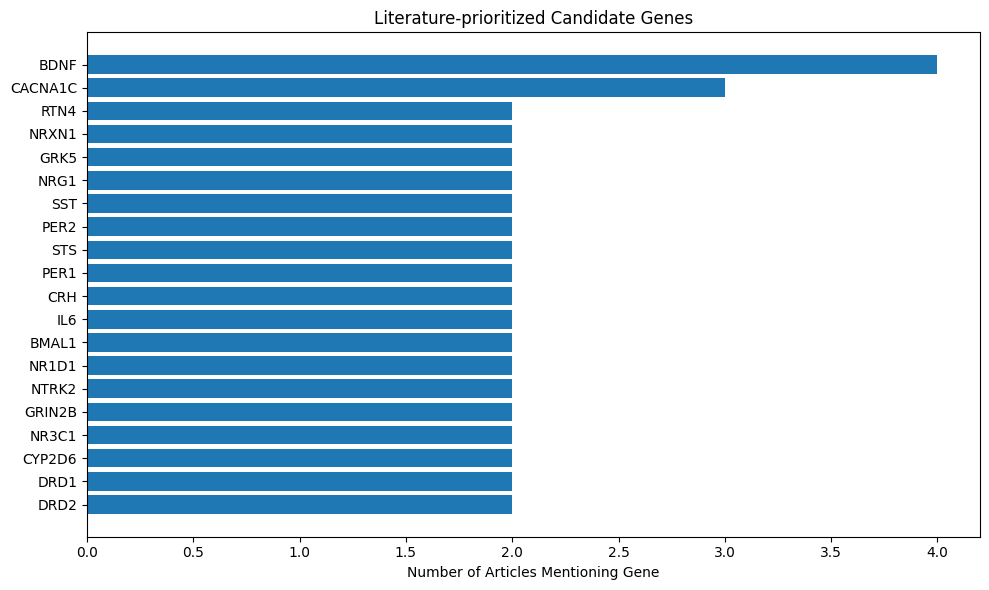

In [25]:
# Plot top candidate genes
top_genes = gene_mentions_df.head(20).sort_values("mention_count", ascending=True)

if len(top_genes) > 0:
    plt.figure(figsize=(10, 6))
    plt.barh(top_genes["gene"], top_genes["mention_count"])
    plt.xlabel("Number of Articles Mentioning Gene")
    plt.title("Literature-prioritized Candidate Genes")
    plt.tight_layout()
    plt.savefig("fig_05_top_candidate_genes.png", dpi=300)
    plt.show()
else:
    print("No gene symbols found. Consider using a broader corpus or adding a curated gene list.")

## Gene–Topic Association

In [26]:
gene_topic_rows = []

for _, row in analysis_df.iterrows():
    for gene in row["mentioned_genes"]:
        gene_topic_rows.append({
            "gene": gene,
            "topic_id": row["dominant_topic"],
            "pmid": row["pmid"]
        })

gene_topic_df = pd.DataFrame(gene_topic_rows)

if len(gene_topic_df) > 0:
    gene_topic_summary = (
        gene_topic_df
        .groupby(["gene", "topic_id"])
        .size()
        .reset_index(name="n_mentions")
        .sort_values(["gene", "n_mentions"], ascending=[True, False])
    )
    display(gene_topic_summary.head(30))
    gene_topic_summary.to_csv("gene_topic_association.csv", index=False)
else:
    gene_topic_summary = pd.DataFrame(columns=["gene", "topic_id", "n_mentions"])
    print("No gene-topic associations available.")

,gene,topic_id,n_mentions
0,ACP1,0,1
1,AHI1,0,1
2,AKAP11,0,1
3,AKT1,1,1
4,ALOX15,0,1
5,ANK3,0,1
6,ANKRD13A,0,1
7,AQP2,2,1
8,ARNT,0,1
9,ATP1A3,0,1


In [27]:
def show_gene_context(df, gene, window=90, max_examples=5):
    gene = gene.upper()
    pattern = re.compile(r"\b" + re.escape(gene) + r"\b")

    examples = []

    for _, row in df.iterrows():
        text = str(row["text"])
        for match in pattern.finditer(text):
            start = max(match.start() - window, 0)
            end = min(match.end() + window, len(text))

            examples.append({
                "gene": gene,
                "pmid": row["pmid"],
                "year": row["year"],
                "title": row["title"],
                "context": text[start:end]
            })

            break

        if len(examples) >= max_examples:
            break

    return pd.DataFrame(examples)


# Example checks
show_gene_context(analysis_df, "BDNF")

,gene,pmid,year,title,context
0,BDNF,41935281,2026,Genetic predictors of lithium response in an e...,t associations were identified between lithium...
1,BDNF,41901356,2026,Genetic Polymorphisms Associated with Lithium ...,ough pharmacogenetic studies implicate polymor...
2,BDNF,37074853,2022,Studies on candidate genes for lithium prophyl...,with lithium prophylactic efficacy were found ...
3,BDNF,35169262,2022,CADPS functional mutations in patients with bi...,/sup> revealed that a decreased level of CADPS...


In [28]:
for g in ["STS", "XKR4", "ESCO1", "HDAC1", "KDM5B", "PAK1"]:
    print("\n" + "="*80)
    print(g)
    display(show_gene_context(analysis_df, g, max_examples=3))


STS


,gene,pmid,year,title,context
0,STS,39995020,2025,Circadian clock genes and cell survival in bip...,"mmortalized mouse hippocampal neurons, lithium..."
1,STS,37126998,2023,Contributions of circadian clock genes to cell...,". control, and Li-R vs. Li-NR cells. In cellul..."



XKR4


,gene,pmid,year,title,context
0,XKR4,38570518,2024,Immunogenetics of lithium response and psychia...,ance abuse and/or suicidal ideation suggested ...
1,XKR4,37461719,2023,Immunogenetics of lithium response and psychia...,ance abuse and/or suicidal ideation at the exp...



ESCO1


...

,gene,pmid,year,title,context
0,HDAC1,41955765,2026,Shared and distinct effects of mood stabilizer...,"ons (acetylation, methylation, phosphorylation..."



KDM5B


,gene,pmid,year,title,context
0,KDM5B,41955765,2026,Shared and distinct effects of mood stabilizer...,", phosphorylation, ubiquitination). Notably, V..."



PAK1


,gene,pmid,year,title,context
0,PAK1,41955765,2026,Shared and distinct effects of mood stabilizer...,"lation, ubiquitination). Notably, VPA upregula..."


In [29]:
high_confidence_genes = {
    "BDNF", "CACNA1C", "DRD1", "DRD2", "NR3C1", "CYP2D6",
    "GRIN2B", "NTRK2", "BMAL1", "NR1D1", "PER1", "PER2",
    "IL6", "CRH", "SST", "FADS1", "RORA"
}

gene_mentions_df["confidence"] = gene_mentions_df["gene"].apply(
    lambda g: "high" if g in high_confidence_genes else "needs_manual_check"
)

final_gene_list = gene_mentions_df[
    gene_mentions_df["confidence"] == "high"
].copy()

final_gene_list.to_csv("candidate_genes.csv", index=False)
gene_mentions_df.to_csv("all_extracted_genes.csv", index=False)

display(final_gene_list)

,gene,mention_count,pmids,n_pmids_listed,confidence
0,BDNF,4,41935281; 41901356; 37074853; 35169262,4,high
1,CACNA1C,3,39233237; 38645236; 37882688,3,high
2,DRD1,2,41935281; 37074853,2,high
3,DRD2,2,41935281; 37074853,2,high
4,NR3C1,2,41901356; 37074853,2,high
5,CYP2D6,2,41795042; 39399035,2,high
6,GRIN2B,2,40810762; 37074853,2,high
7,NTRK2,2,40810762; 37074853,2,high
8,BMAL1,2,40681844; 39995020,2,high
9,NR1D1,2,39995020; 39831746,2,high
